# CIT 306 – Deep Learning Project

## Deep Learning-Based Image Classification Using Python

### Dataset: Fashion-MNIST
### Tool: Google Colab


- Student Name: Abdullah Alatwi

In [11]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

In [12]:
# Load Fashion-MNIST dataset
(train_images, train_labels), (test_images, test_labels) = datasets.fashion_mnist.load_data()

# Print dataset shapes
print("Training images shape:", train_images.shape)
print("Training labels shape:", train_labels.shape)
print("Testing images shape:", test_images.shape)
print("Testing labels shape:", test_labels.shape)

Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing images shape: (10000, 28, 28)
Testing labels shape: (10000,)


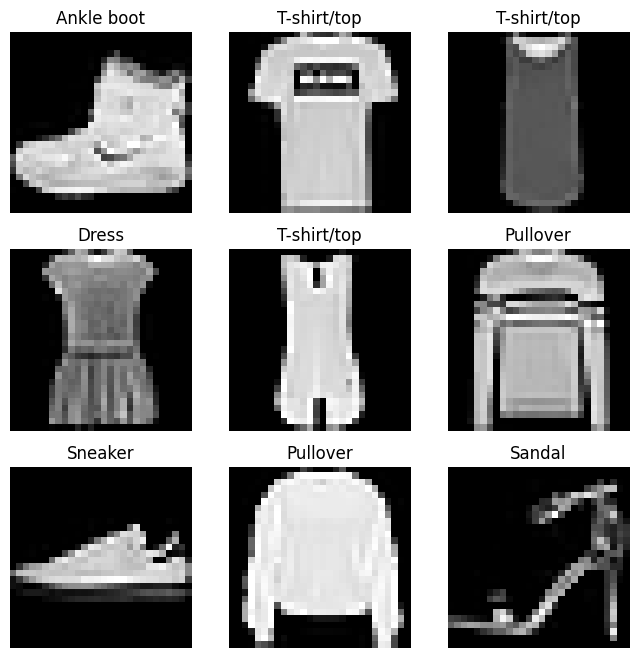

In [13]:
# Class names for Fashion-MNIST dataset
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

# Display sample images
plt.figure(figsize=(8, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(train_images[i], cmap='gray')
    plt.title(class_names[train_labels[i]])
    plt.axis('off')

plt.show()

### Data Visualization Result

The displayed images show different clothing items from the Fashion-MNIST dataset, such as shoes, shirts, dresses, and sandals.  
This step helps us understand the dataset before building the deep learning model.

## Data Preprocessing

In this step, we normalize the image pixel values from the range 0–255 to the range 0–1.  
Normalization helps the model train faster and more stable.

In [14]:
# Normalize pixel values to be between 0 and 1
train_images = train_images / 255.0
test_images = test_images / 255.0

# Check minimum and maximum pixel values after normalization
print("Minimum pixel value:", train_images.min())
print("Maximum pixel value:", train_images.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [15]:
# Build the neural network model
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Show model summary
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully.")

Model compiled successfully.


In [17]:
# Train the model
history = model.fit(
    train_images,
    train_labels,
    epochs=5,
    validation_split=0.2
)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8161 - loss: 0.5201 - val_accuracy: 0.8578 - val_loss: 0.3949
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8607 - loss: 0.3820 - val_accuracy: 0.8592 - val_loss: 0.3751
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8738 - loss: 0.3435 - val_accuracy: 0.8616 - val_loss: 0.3882
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8818 - loss: 0.3192 - val_accuracy: 0.8783 - val_loss: 0.3455
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8884 - loss: 0.3003 - val_accuracy: 0.8791 - val_loss: 0.3550


In [18]:
# Evaluate the model on test data
test_loss, test_accuracy = model.evaluate(test_images, test_labels)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8734 - loss: 0.3751
Test Loss: 0.3750855624675751
Test Accuracy: 0.8733999729156494


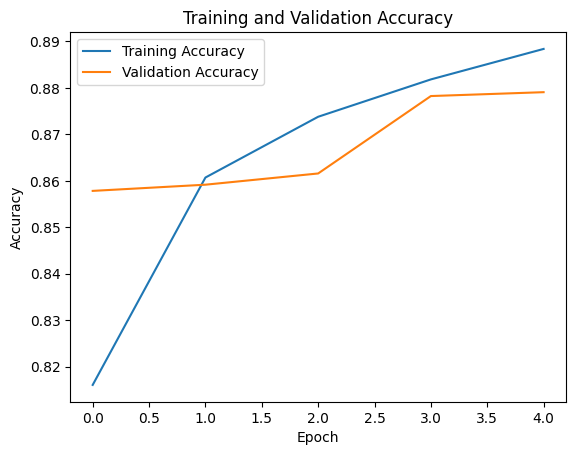

In [19]:
# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
Predicted labels: [9 2 1 1 6]
True labels: [9 2 1 1 6]


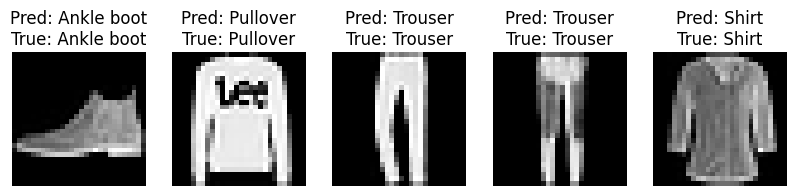

In [20]:
# Make predictions on the first 5 test images
predictions = model.predict(test_images[:5])

# Convert probabilities to class labels
predicted_labels = np.argmax(predictions, axis=1)

print("Predicted labels:", predicted_labels)
print("True labels:", test_labels[:5])

# Show prediction results with images
plt.figure(figsize=(10, 4))

for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(test_images[i], cmap='gray')
    plt.title("Pred: " + class_names[predicted_labels[i]] + "\nTrue: " + class_names[test_labels[i]])
    plt.axis('off')

plt.show()